# 03. 전처리 (Preprocessing)

**처리 순서**
1. 피처 테이블 로드
2. 결측치 처리
3. 이상치 처리 (1~99 percentile 캡핑)
4. Train/Test Split
5. 클래스 불균형 처리 (SMOTE — train 셋만)
6. 다중공선성 제거 (Pearson ≥ 0.7) + Mutual Information 기반 피처 선택
7. 스케일링 (LR 전용 — train fit, test transform)
8. 저장

---
## 1. 라이브러리 & 설정

In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE

plt.style.use('seaborn-v0_8')
sns.set_theme(font_scale=1.5)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

os.makedirs('../data/interim', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

print("라이브러리 로드 완료")

라이브러리 로드 완료


---
## 2. 피처 테이블 로드

In [19]:
# features_selected.parquet 우선, 없으면 features.parquet 대체
selected_path = '../data/interim/features.parquet'

df = pd.read_parquet(selected_path)
print(f"[로드] {selected_path}")

print(f"shape : {df.shape}")
print(f"컬럼  : {df.columns.tolist()}")
print()
df.head()

[로드] ../data/interim/features.parquet
shape : (84371, 9)
컬럼  : ['customer_unique_id', 'label', 'avg_delay', 'max_delay', 'delay_order_count', 'total_orders', 'delay_rate', 'is_ever_delayed', 'recency_days']



,customer_unique_id,label,avg_delay,max_delay,delay_order_count,total_orders,delay_rate,is_ever_delayed,recency_days
0,7c396fd4830fd04220f754e42b4e5bff,1,-9.0,-8,0,2,0.0,0,290
1,7c142cf63193a1473d2e66489a9ae977,1,-13.0,-13,0,1,0.0,0,242
2,72632f0f9dd73dfee390c9b22eb56dd6,1,-10.0,-10,0,1,0.0,0,155
3,80bb27c7c16e8f973207a5086ab329e2,1,-6.0,-6,0,1,0.0,0,374
4,932afa1e708222e5821dac9cd5db4cae,1,-12.0,-12,0,1,0.0,0,429


---
## 3. 결측치 처리

| 컬럼 | 처리 전략 |
|------|----------|
| `avg_delay`, `max_delay`, `delay_rate`, `is_ever_delayed` | 0으로 대체 (지연 없음으로 해석) |
| `recency_days` | 결측 없음 (cutoff 이전 구매 고객 전체 대상으로 계산됨) |

In [20]:
print("=== 결측치 처리 전 ===")
print(df.isnull().sum())
print(f"\n총 결측치: {df.isnull().sum().sum()}")

=== 결측치 처리 전 ===
customer_unique_id    0
label                 0
avg_delay             0
max_delay             0
delay_order_count     0
total_orders          0
delay_rate            0
is_ever_delayed       0
recency_days          0
dtype: int64

총 결측치: 0


In [21]:
# ── 배송 지연 관련 결측 처리 ──────────────────────────────────────────
delay_cols = ['avg_delay', 'max_delay', 'delay_rate', 'is_ever_delayed']
existing_delay = [c for c in delay_cols if c in df.columns]
if existing_delay:
    df[existing_delay] = df[existing_delay].fillna(0)
    print(f"[처리] {existing_delay}: 0으로 대체 완료")

# ── 처리 후 결측치 확인 ────────────────────────────────────────────────
print("\n=== 결측치 처리 후 ===")
print(df.isnull().sum())
assert df.isnull().sum().sum() == 0, "결측치 잔존 — 처리 로직 재검토 필요"
print("\n[검증] 결측치 없음 OK")

[처리] ['avg_delay', 'max_delay', 'delay_rate', 'is_ever_delayed']: 0으로 대체 완료

=== 결측치 처리 후 ===
customer_unique_id    0
label                 0
avg_delay             0
max_delay             0
delay_order_count     0
total_orders          0
delay_rate            0
is_ever_delayed       0
recency_days          0
dtype: int64

[검증] 결측치 없음 OK


---
## 4. 이상치 처리 (1~99 percentile 캡핑)

- 캡핑 대상: `avg_delay`, `max_delay`, `delay_rate`, `recency_days`
- `is_ever_delayed`, `delay_order_count`, `total_orders`는 정수형 카운트 → 캡핑 없이 분포만 출력
- 캡핑은 train/test split 이전, 전체 데이터 기준으로 적용

In [22]:
# ── 연속형 피처 캡핑 ─────────────────────────────────────────────────
cap_cols = ['avg_delay', 'max_delay', 'delay_rate', 'recency_days']
existing_cap = [c for c in cap_cols if c in df.columns]

print("=== 캡핑 전후 비교 (1~99 percentile) ===")
print(f"{'피처':<20} {'before_min':>12} {'before_max':>12} {'before_mean':>12} "
      f"{'after_min':>12} {'after_max':>12} {'after_mean':>12}")
print("-" * 96)

clip_bounds = {}
for col in existing_cap:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    clip_bounds[col] = (p01, p99)

    before_min  = df[col].min()
    before_max  = df[col].max()
    before_mean = df[col].mean()

    df[col] = df[col].clip(lower=p01, upper=p99)

    after_min  = df[col].min()
    after_max  = df[col].max()
    after_mean = df[col].mean()

    print(f"{col:<20} {before_min:>12.3f} {before_max:>12.3f} {before_mean:>12.3f} "
          f"{after_min:>12.3f} {after_max:>12.3f} {after_mean:>12.3f}")
    print(f"  → 캡핑 범위: [{p01:.3f}, {p99:.3f}]")

print()

# ── is_ever_delayed 이진 분포 출력 ───────────────────────────────────
if 'is_ever_delayed' in df.columns:
    vc = df['is_ever_delayed'].value_counts()
    vr = df['is_ever_delayed'].value_counts(normalize=True)
    print("=== is_ever_delayed 값 분포 (캡핑 없음 — 이진값) ===")
    print(f"  0 (지연 없음): {vc.get(0, 0):,}명  ({vr.get(0, 0):.1%})")
    print(f"  1 (지연 있음): {vc.get(1, 0):,}명  ({vr.get(1, 0):.1%})")

=== 캡핑 전후 비교 (1~99 percentile) ===
피처                     before_min   before_max  before_mean    after_min    after_max   after_mean
------------------------------------------------------------------------------------------------
avg_delay                -147.000      188.000      -12.175      -36.000       19.000      -12.277
  → 캡핑 범위: [-36.000, 19.000]
max_delay                -147.000      188.000      -12.047      -36.000       20.000      -12.145
  → 캡핑 범위: [-36.000, 20.000]
delay_rate                  0.000        1.000        0.070        0.000        1.000        0.070
  → 캡핑 범위: [0.000, 1.000]
recency_days                0.000      672.000      219.487        3.000      535.000      219.100
  → 캡핑 범위: [3.000, 535.000]

=== is_ever_delayed 값 분포 (캡핑 없음 — 이진값) ===
  0 (지연 없음): 78,373명  (92.9%)
  1 (지연 있음): 5,998명  (7.1%)


---
## 5. Train/Test Split

- 비율: 8:2
- `random_state=42`, `stratify=y`
- **스케일링보다 반드시 먼저 수행**

In [23]:
# label 및 식별자 컬럼 제외
drop_cols = [c for c in ['customer_unique_id', 'label'] if c in df.columns]
X = df.drop(columns=drop_cols)
y = df['label']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"피처 목록: {X.columns.tolist()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape[0]:,}행  /  Test: {X_test.shape[0]:,}행")

# ── 클래스 비율 확인 ──────────────────────────────────────────────────
print("\n=== Train 레이블 클래스 비율 ===")
train_dist = y_train.value_counts(normalize=True)
print(f"  유지 (0): {train_dist.get(0, 0):.1%}")
print(f"  이탈 (1): {train_dist.get(1, 0):.1%}")

print("\n=== Test 레이블 클래스 비율 ===")
test_dist = y_test.value_counts(normalize=True)
print(f"  유지 (0): {test_dist.get(0, 0):.1%}")
print(f"  이탈 (1): {test_dist.get(1, 0):.1%}")

X shape: (84371, 7)
y shape: (84371,)
피처 목록: ['avg_delay', 'max_delay', 'delay_order_count', 'total_orders', 'delay_rate', 'is_ever_delayed', 'recency_days']

Train: 67,496행  /  Test: 16,875행

=== Train 레이블 클래스 비율 ===
  유지 (0): 0.3%
  이탈 (1): 99.7%

=== Test 레이블 클래스 비율 ===
  유지 (0): 0.3%
  이탈 (1): 99.7%


---
## 6. 클래스 불균형 처리 — SMOTE (train 셋 전용)

> **주의**: SMOTE는 train 셋에만 적용. test 셋에는 적용 금지.  
> 균형 잡힌 train 데이터를 기준으로 상관계수 분석을 수행하면 피처 상관계수가 더 신뢰할 수 있는 값을 나타냄

In [24]:
print("=== SMOTE 적용 전 Train 클래스 분포 ===")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).round(3))

sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

print("\n=== SMOTE 적용 후 Train 클래스 분포 ===")
smote_dist  = pd.Series(y_train_smote).value_counts()
smote_ratio = pd.Series(y_train_smote).value_counts(normalize=True)
print(f"  유지 (0): {smote_dist.get(0, 0):,}명  ({smote_ratio.get(0, 0):.1%})")
print(f"  이탈 (1): {smote_dist.get(1, 0):,}명  ({smote_ratio.get(1, 0):.1%})")
print(f"  전체     : {len(y_train_smote):,}명")

X_train_smote = pd.DataFrame(X_train_smote, columns=X_train.columns)
y_train_smote = pd.Series(y_train_smote, name='label')

print("\n[검증] Test 셋 변경 없음")
print(f"  X_test shape: {X_test.shape}  (SMOTE 미적용)")

=== SMOTE 적용 전 Train 클래스 분포 ===
label
1    67310
0      186
Name: count, dtype: int64
label
1    0.997
0    0.003
Name: proportion, dtype: float64

=== SMOTE 적용 후 Train 클래스 분포 ===
  유지 (0): 67,310명  (50.0%)
  이탈 (1): 67,310명  (50.0%)
  전체     : 134,620명

[검증] Test 셋 변경 없음
  X_test shape: (16875, 7)  (SMOTE 미적용)


---

## 7. SMOTE 균형 train 기준 상관계수 행렬 계산

In [25]:
train_smote_with_label = X_train_smote.copy()
train_smote_with_label['label'] = y_train_smote.values

numeric_cols = train_smote_with_label.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != 'label']

corr_matrix = train_smote_with_label[feature_cols].corr(method='pearson')

---

## 8. 히트맵 시각화

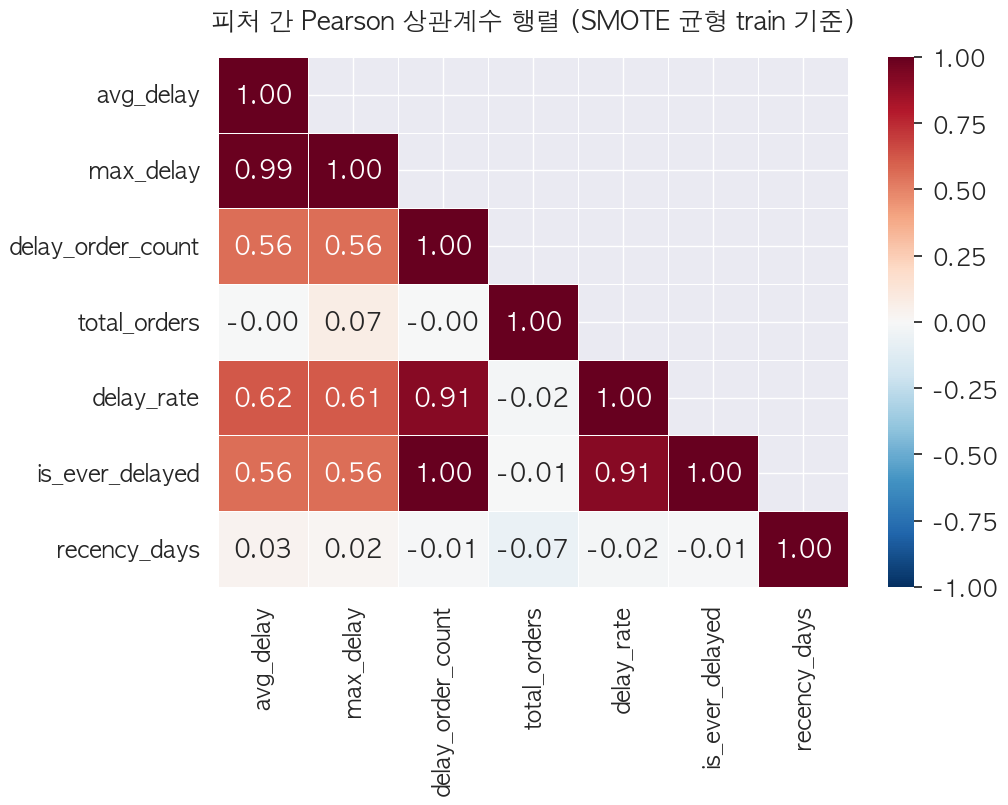

[저장] ../outputs/correlation_heatmap.png


In [26]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(max(10, len(feature_cols) * 1.5),
                                max(8,  len(feature_cols) * 1.2)))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('피처 간 Pearson 상관계수 행렬 (SMOTE 균형 train 기준)', pad=20)
plt.tight_layout()
heatmap_path = '../outputs/correlation_heatmap.png'
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"[저장] {heatmap_path}")

---

In [27]:
# ── 절댓값 0.7 이상 쌍 추출 (다중공선성 제거) ────────────────────────
high_corr_pairs = []
checked = set()

for i, f1 in enumerate(feature_cols):
    for f2 in feature_cols[i+1:]:
        pair_key = tuple(sorted([f1, f2]))
        if pair_key in checked:
            continue
        checked.add(pair_key)
        val = corr_matrix.loc[f1, f2]
        if abs(val) >= 0.7:
            high_corr_pairs.append({'피처1': f1, '피처2': f2, '상관계수': round(val, 4)})

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(f"=== 상관계수 절댓값 ≥ 0.7 피처 쌍 ({len(high_corr_df)}개) ===")
    print(high_corr_df.to_string(index=False))
else:
    high_corr_df = pd.DataFrame(columns=['피처1', '피처2', '상관계수'])
    print("상관계수 절댓값 0.7 이상인 피처 쌍 없음 — 제거 대상 없음")

=== 상관계수 절댓값 ≥ 0.7 피처 쌍 (4개) ===
              피처1             피처2   상관계수
        avg_delay       max_delay 0.9901
delay_order_count      delay_rate 0.9107
delay_order_count is_ever_delayed 0.9975
       delay_rate is_ever_delayed 0.9132


In [28]:
# ── Mutual Information (비선형 포함 피처-레이블 관계 측정) ─────────────
mi_values = mutual_info_classif(
    X_train_smote[feature_cols], y_train_smote, random_state=42
)
mi_series = pd.Series(mi_values, index=feature_cols).sort_values(ascending=False)

print("=== 피처별 Mutual Information (SMOTE 균형 train 기준) ===")
print(mi_series.round(4))

=== 피처별 Mutual Information (SMOTE 균형 train 기준) ===
avg_delay            0.5709
recency_days         0.1235
delay_rate           0.0200
max_delay            0.0196
total_orders         0.0167
delay_order_count    0.0083
is_ever_delayed      0.0077
dtype: float64


In [29]:
drop_candidates = set()
drop_records = []

for _, row in high_corr_df.iterrows():
    f1, f2 = row['피처1'], row['피처2']
    mi_f1 = mi_series.get(f1, 0)
    mi_f2 = mi_series.get(f2, 0)
    if mi_f1 <= mi_f2:
        drop_feat, keep_feat = f1, f2
        drop_score, keep_score = mi_f1, mi_f2
    else:
        drop_feat, keep_feat = f2, f1
        drop_score, keep_score = mi_f2, mi_f1
    drop_candidates.add(drop_feat)
    drop_records.append({
        '피처 쌍': f"{f1} & {f2}",
        '상관계수': row['상관계수'],
        '제거 후보': drop_feat,
        '제거 후보 MI': round(drop_score, 4),
        '유지': keep_feat,
        '유지 MI': round(keep_score, 4)
    })

if drop_records:
    print("=== 제거 후보 피처 (MI 기준) ===")
    print(pd.DataFrame(drop_records).to_string(index=False))
else:
    print("제거 후보 없음")

# ── 최종 피처 목록 확정 및 적용 ───────────────────────────────────────
final_features = [c for c in feature_cols if c not in drop_candidates]
print(f"\n=== 최종 피처 목록 ({len(final_features)}개) ===")
for f in final_features:
    print(f"  - {f}")

X_train_smote = X_train_smote[final_features].copy()
X_train       = X_train[final_features].copy()
X_test        = X_test[final_features].copy()

print(f"\nX_train_smote shape: {X_train_smote.shape}")
print(f"X_test        shape: {X_test.shape}")

=== 제거 후보 피처 (MI 기준) ===
                               피처 쌍   상관계수             제거 후보  제거 후보 MI                유지  유지 MI
              avg_delay & max_delay 0.9901         max_delay    0.0196         avg_delay 0.5709
     delay_order_count & delay_rate 0.9107 delay_order_count    0.0083        delay_rate 0.0200
delay_order_count & is_ever_delayed 0.9975   is_ever_delayed    0.0077 delay_order_count 0.0083
       delay_rate & is_ever_delayed 0.9132   is_ever_delayed    0.0077        delay_rate 0.0200

=== 최종 피처 목록 (4개) ===
  - avg_delay
  - total_orders
  - delay_rate
  - recency_days

X_train_smote shape: (134620, 4)
X_test        shape: (16875, 4)


In [30]:
# ── 제거 후보 반영하여 최종 피처 목록 확정 ───────────────────────────
final_features = [c for c in feature_cols if c not in drop_candidates]
print(f"=== 최종 피처 목록 ({len(final_features)}개) ===")
for f in final_features:
    print(f"  - {f}")

# train/test에 최종 피처만 남기기
X_train = X_train[final_features].copy()
X_test  = X_test[final_features].copy()

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")

=== 최종 피처 목록 (4개) ===
  - avg_delay
  - total_orders
  - delay_rate
  - recency_days

X_train shape: (67496, 4)
X_test  shape: (16875, 4)


In [31]:
scaler = StandardScaler()

# SMOTE 균형 train 기준 fit → train & test transform
X_train_scaled_arr = scaler.fit_transform(X_train_smote)
X_test_scaled_arr  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled_arr, columns=final_features)
X_test_scaled  = pd.DataFrame(X_test_scaled_arr,  columns=final_features)

print("=== 스케일링 완료 (LR 전용) ===")
print(f"X_train_scaled shape: {X_train_scaled.shape}  (SMOTE 균형 기준)")
print(f"X_test_scaled  shape: {X_test_scaled.shape}")
print("\n[검증] train 스케일링 후 각 피처 mean ≈ 0, std ≈ 1")
print(X_train_scaled.describe().loc[['mean', 'std']].round(3))

=== 스케일링 완료 (LR 전용) ===
X_train_scaled shape: (134620, 4)  (SMOTE 균형 기준)
X_test_scaled  shape: (16875, 4)

[검증] train 스케일링 후 각 피처 mean ≈ 0, std ≈ 1
      avg_delay  total_orders  delay_rate  recency_days
mean       -0.0           0.0        -0.0           0.0
std         1.0           1.0         1.0           1.0


---
## 9. 스케일링 (Logistic Regression 베이스라인 전용)

- LightGBM / XGBoost에는 스케일링 불필요
- `scaler.fit()`: train 기준으로만
- `scaler.transform()`: test에는 transform만

In [32]:
# y_train / y_test를 DataFrame으로 변환 후 저장
y_train_df = y_train.reset_index(drop=True).to_frame(name='label')
y_test_df  = y_test.reset_index(drop=True).to_frame(name='label')

save_map = {
    '../data/interim/X_train.parquet'       : X_train.reset_index(drop=True),          # 원본 (참조용)
    '../data/interim/X_test.parquet'        : X_test.reset_index(drop=True),
    '../data/interim/y_train.parquet'       : y_train_df,
    '../data/interim/y_test.parquet'        : y_test_df,
    '../data/interim/X_train_smote.parquet' : X_train_smote.reset_index(drop=True),    # SMOTE + 피처 선정
    '../data/interim/y_train_smote.parquet' : y_train_smote.reset_index(drop=True).to_frame(name='label'),
    '../data/interim/X_train_scaled.parquet': X_train_scaled.reset_index(drop=True),   # LR용 (SMOTE 균형 + 스케일)
    '../data/interim/X_test_scaled.parquet' : X_test_scaled.reset_index(drop=True),
}

print("=== 저장 결과 ===")
for path, data in save_map.items():
    data.to_parquet(path, index=False)
    size_kb = os.path.getsize(path) / 1024
    print(f"  [OK] {path}  shape={data.shape}  ({size_kb:.1f} KB)")

print("\n모든 파일 저장 완료")

=== 저장 결과 ===
  [OK] ../data/interim/X_train.parquet  shape=(67496, 4)  (168.5 KB)
  [OK] ../data/interim/X_test.parquet  shape=(16875, 4)  (44.5 KB)
  [OK] ../data/interim/y_train.parquet  shape=(67496, 1)  (2.2 KB)
  [OK] ../data/interim/y_test.parquet  shape=(16875, 1)  (1.4 KB)
  [OK] ../data/interim/X_train_smote.parquet  shape=(134620, 4)  (925.4 KB)
  [OK] ../data/interim/y_train_smote.parquet  shape=(134620, 1)  (2.4 KB)
  [OK] ../data/interim/X_train_scaled.parquet  shape=(134620, 4)  (928.2 KB)
  [OK] ../data/interim/X_test_scaled.parquet  shape=(16875, 4)  (47.1 KB)

모든 파일 저장 완료


---
## 10. 저장

In [33]:
# y_train / y_test를 DataFrame으로 변환 후 저장
y_train_df = y_train.reset_index(drop=True).to_frame(name='label')
y_test_df  = y_test.reset_index(drop=True).to_frame(name='label')

save_map = {
    '../data/interim/X_train.parquet'       : X_train.reset_index(drop=True),
    '../data/interim/X_test.parquet'        : X_test.reset_index(drop=True),
    '../data/interim/y_train.parquet'       : y_train_df,
    '../data/interim/y_test.parquet'        : y_test_df,
    '../data/interim/X_train_smote.parquet' : X_train_smote.reset_index(drop=True),
    '../data/interim/y_train_smote.parquet' : y_train_smote.reset_index(drop=True).to_frame(name='label'),
    '../data/interim/X_train_scaled.parquet': X_train_scaled.reset_index(drop=True),
    '../data/interim/X_test_scaled.parquet' : X_test_scaled.reset_index(drop=True),
}

print("=== 저장 결과 ===")
for path, data in save_map.items():
    data.to_parquet(path, index=False)
    size_kb = os.path.getsize(path) / 1024
    print(f"  [OK] {path}  shape={data.shape}  ({size_kb:.1f} KB)")

print("\n모든 파일 저장 완료")

=== 저장 결과 ===
  [OK] ../data/interim/X_train.parquet  shape=(67496, 4)  (168.5 KB)
  [OK] ../data/interim/X_test.parquet  shape=(16875, 4)  (44.5 KB)
  [OK] ../data/interim/y_train.parquet  shape=(67496, 1)  (2.2 KB)
  [OK] ../data/interim/y_test.parquet  shape=(16875, 1)  (1.4 KB)
  [OK] ../data/interim/X_train_smote.parquet  shape=(134620, 4)  (925.4 KB)
  [OK] ../data/interim/y_train_smote.parquet  shape=(134620, 1)  (2.4 KB)
  [OK] ../data/interim/X_train_scaled.parquet  shape=(134620, 4)  (928.2 KB)
  [OK] ../data/interim/X_test_scaled.parquet  shape=(16875, 4)  (47.1 KB)

모든 파일 저장 완료


---
## 최종 체크리스트

In [34]:
print("=== 최종 체크리스트 ===")

checks = [
    ("결측치 없음",
     X_train.isnull().sum().sum() == 0 and X_test.isnull().sum().sum() == 0),
    ("train/test shape 비율 약 8:2",
     abs(len(X_train) / (len(X_train) + len(X_test)) - 0.8) < 0.02),
    ("SMOTE는 train에만 적용 (test shape 변화 없음)",
     X_test.shape[0] == y_test.shape[0]),
    ("스케일링: train mean ≈ 0",
     (X_train_scaled.mean().abs() < 0.01).all()),
    ("스케일링: train std ≈ 1",
     ((X_train_scaled.std() - 1).abs() < 0.01).all()),
    ("저장 파일 모두 존재",
     all(os.path.exists(p) for p in save_map.keys())),
]

all_pass = True
for name, result in checks:
    status = 'O' if result else 'X'
    if not result:
        all_pass = False
    print(f"  [{status}] {name}")

print()
if all_pass:
    print("전처리 파이프라인 완료 — 모든 체크 통과")
else:
    print("[경고] 일부 체크 실패 — 위 항목 재검토 필요")

=== 최종 체크리스트 ===
  [O] 결측치 없음
  [O] train/test shape 비율 약 8:2
  [O] SMOTE는 train에만 적용 (test shape 변화 없음)
  [O] 스케일링: train mean ≈ 0
  [O] 스케일링: train std ≈ 1
  [O] 저장 파일 모두 존재

전처리 파이프라인 완료 — 모든 체크 통과
